In [1]:
import matplotlib.pyplot as plt

NUM_EPOCHS = 100
def schedular_lr(optimizer, schedular):
    lr_history = []
    epoch_history = []
    """optimizer的更新在scheduler更新的前面"""
    for epoch in range(NUM_EPOCHS):
        optimizer.step() # 更新参数
        lr_history.append(optimizer.param_groups[0]['lr'])
        schedular.step() # 调整学习率
    plt.plot(lr_history)
    return lr_history

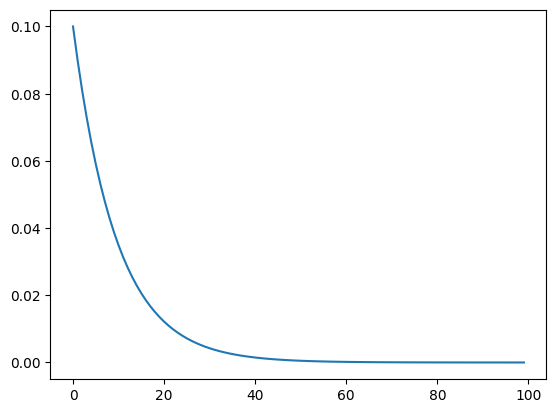

In [ ]:
# ------------------------------------------------------ 使用LambdaLR 调度器 做的最常见的学习率调整， 每个opoch 其学习率下降为0.9^epoch ------------------------------------------------------
import torch
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler

# 定义模型和优化器
model = torch.nn.Linear(10, 2)  # 示例模型
optimizer = optim.SGD(model.parameters(), lr=0.1)

# 定义 Lambda 函数
def lr_lambda(epoch):
    return 0.9 ** epoch  # 每个 epoch 学习率乘以 0.9

# 创建 LambdaLR 调度器
scheduler = lr_scheduler.LambdaLR(optimizer, lr_lambda)

lr_his = schedular_lr(optimizer, scheduler)

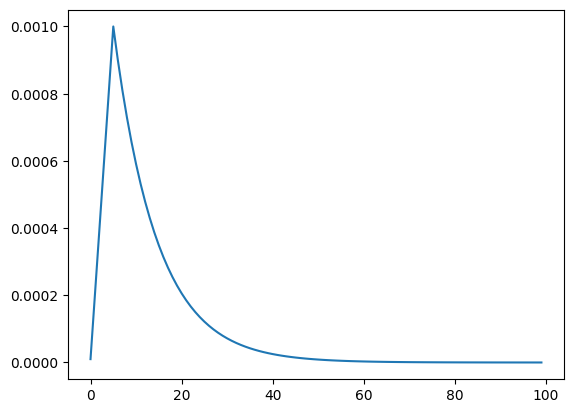

In [ ]:
#-------------------------------------------- StepLR + warmup 方式1：（我更喜欢这种写法）--------------------------------------------

import torch
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler

# 定义模型和优化器
model = torch.nn.Linear(10, 2)  # 示例模型

global_Initialize_lr = 0.1
optimizer = optim.SGD(model.parameters(), lr=global_Initialize_lr)

warmup_epochs = 5
# 定义 Lambda 函数
# !!!!! lr_lambda 函数的返回值应该是一个乘数（相对于初始学习率），而不是绝对学习率值!!!!!
def lr_lambda(epoch):
    if epoch< warmup_epochs:
        initial_lr = 0.00001  # 初始学习率
        target_lr = 0.001  # 目标学习率
        return (initial_lr + (target_lr-initial_lr)*(epoch / warmup_epochs))/global_Initialize_lr   # optimizer.param_groups[0]['lr']
    else:
        initial_lr = 0.001/global_Initialize_lr
        return  initial_lr * 0.9 ** (epoch - warmup_epochs)

# 创建 LambdaLR 调度器
scheduler = lr_scheduler.LambdaLR(optimizer, lr_lambda)

lr_his = schedular_lr(optimizer, scheduler)

In [13]:
optimizer.param_groups[0]['lr']

4.498196224760375e-08

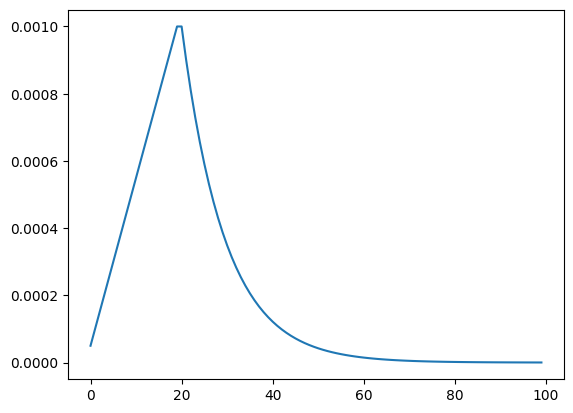

In [ ]:
# -------------------------------------------------------------- StepLR + warmup 方式2
import torch
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler

# 定义模型和优化器
model = torch.nn.Linear(10, 2)  # 示例模型
optimizer = optim.SGD(model.parameters(), lr=0.001)  # 初始学习率

warmup_epochs = 20

# 定义 Lambda 函数
def lr_lambda(epoch):  # epoch在 每次 schedular_lr 都会执行 +1 操作，其初始值为 -1， 具体的理解参考下方的伪代码!!!
    if epoch < warmup_epochs:
        # Warmup 阶段：线性增加学习率
        return (epoch+1) / warmup_epochs  # 返回相对于初始学习率的乘数
    else:
        # 后续阶段：指数衰减学习率
        return 0.9 ** (epoch - warmup_epochs)

# 创建 LambdaLR 调度器
scheduler = lr_scheduler.LambdaLR(optimizer, lr_lambda)  # !!!!! lr_lambda 函数的返回值应该是一个乘数（相对于初始学习率），而不是绝对学习率值!!!!!
lr_his = schedular_lr(optimizer, scheduler)

In [8]:
lr_his[:5]

[0.0, 5e-05, 0.0001, 0.00015, 0.0002]

In [ ]:
############################################ 其中 LambdaLR 的实现的伪代码 如下 ###############################################################

class LambdaLR:
    def __init__(self, optimizer, lr_lambda):
        self.optimizer = optimizer
        self.lr_lambda = lr_lambda
        self.last_epoch = -1  # 初始化计数器

    def step(self):
        self.last_epoch += 1  # 更新计数器  ======》 
        """
        每次调用 step() 都会更新 last_epoch， 所以说这个参数，每个是每个step 或 epoch 更新的都是 self.last_epoch
        EG: 如果是每个step都调用，则每个step都会更新一次 self.last_epoch
        >>> for epoch in range(10):
        ...     for step in range(100):
        ...         scheduler.step()
        ...         print(scheduler.last_epoch)
        # 如果 每个epoch都调用，则每个epoch都会更新一次 self.last_epoch
        >>> for epoch in range(100):
        ...     scheduler.step()
        ...     print(scheduler.last_epoch)
        
        
        
        """
        lr_factor = self.lr_lambda(self.last_epoch)  # 调用 lr_lambda 函数

        # 调整优化器的学习率
        for param_group in self.optimizer.param_groups:
            param_group['lr'] *= lr_factor
